# **PrimeTrade.ai Data Science Assignment**

**Objective**

The objective of this project is to analyze how cryptocurrency market sentiment affects trader performance and trading behavior using Hyperliquid trading data and the Fear & Greed Index dataset.

Using exploratory data analysis and visualization techniques, the project aims to identify patterns in profitability, win rates, trading activity, and market participation under different market sentiment conditions.

**Importing Libraries**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

**Loading Datasets**

In [ ]:
from google.colab import files
trades = files.upload() # historical_data.csv

In [ ]:
sentiment = files.upload() # fear_greed_index.csv

In [36]:
trades = pd.read_csv('historical_data.csv')

sentiment = pd.read_csv('fear_greed_index.csv')

**Data Cleaning & Preprocessing**

In [7]:
display(trades.head())

display(sentiment.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
print(trades.columns)

print("\n------------------\n")

print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

------------------

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [9]:
print(trades.isnull().sum())

print("\n-----------------\n")

print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                1
Timestamp IST       1
Start Position      1
Direction           1
Closed PnL          1
Transaction Hash    1
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64

-----------------

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [10]:
# Convert trader timestamp to datetime
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Extract date only
trades['date'] = trades['Timestamp IST'].dt.date


# Convert sentiment date
sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

print("Date conversion successful!")

Date conversion successful!


**Dataset Merging**

In [12]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [14]:
print(merged['classification'].value_counts())

classification
Fear             36200
Greed            35139
Neutral          24578
Extreme Greed    21504
Extreme Fear      8403
Name: count, dtype: int64



**Average Profitability Analysis**

In [15]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

print(avg_pnl)

classification
Extreme Fear     69.691964
Extreme Greed    85.831404
Fear             73.783558
Greed            35.398986
Neutral          48.951258
Name: Closed PnL, dtype: float64


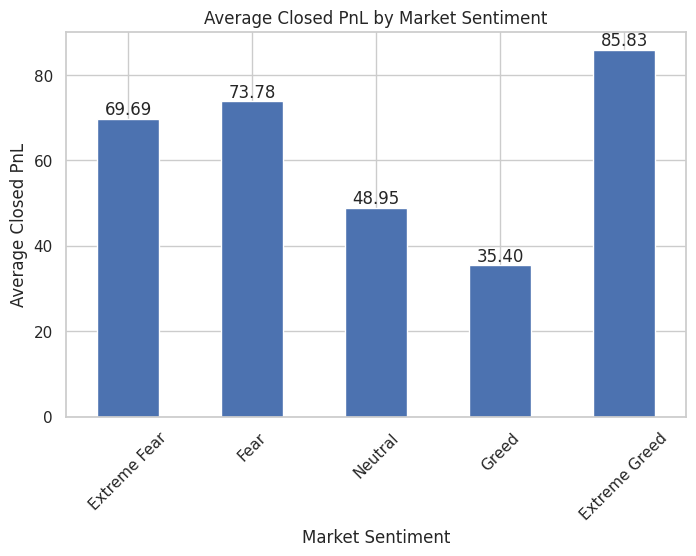

In [16]:
order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

avg_pnl = avg_pnl.reindex(order)

ax = avg_pnl.plot(kind='bar',figsize=(8,5))

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)
# Add values on top of bars
for i, v in enumerate(avg_pnl):
    ax.text(i,v + 1,f"{v:.2f}",ha='center')

plt.show()

## Insight

Average trader profitability increased as market sentiment became more optimistic.

Extreme Greed conditions generated the highest average profits, indicating stronger bullish momentum and improved trading opportunities.

In contrast, Neutral and Greed conditions showed comparatively lower profitability, suggesting that market sentiment significantly influences trading performance.

**Win Rate Analysis**

In [17]:
merged['win'] = merged['Closed PnL'] > 0

In [21]:
win_rate = merged.groupby('classification')['win'].mean() * 100
print(win_rate)

classification
Extreme Fear     35.653933
Extreme Greed    45.121838
Fear             43.743094
Greed            35.837673
Neutral          41.016356
Name: win, dtype: float64


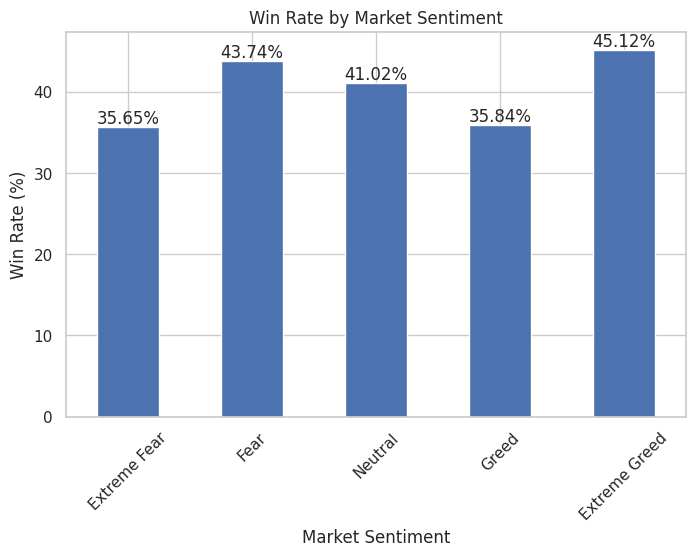

In [22]:
win_rate = win_rate.reindex(order)

ax = win_rate.plot(kind='bar',figsize=(8,5))

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

# Add values on top of bars
for i, v in enumerate(win_rate):
    ax.text(
        i,               # x-position
        v + 0.5,         # y-position
        f"{v:.2f}%",     # text format
        ha='center'
    )

plt.show()

## Insight

The highest win rate was observed during Extreme Greed periods, while Extreme Fear recorded the lowest win rate.

Although win rates across sentiment categories remained relatively close, profitability varied much more significantly.

This suggests that market sentiment affects the size of trading gains and losses more strongly than the probability of winning trades.

**Buy/Sell Behavioral Analysis**

In [23]:
# Create Buy/Sell Table

trade_behavior = pd.crosstab(merged['classification'],merged['Side'])
trade_behavior = trade_behavior.reindex(order)
print(trade_behavior)

Side              BUY   SELL
classification              
Extreme Fear     4718   3685
Fear            18008  18192
Neutral         13009  11569
Greed           17993  17146
Extreme Greed    9744  11760


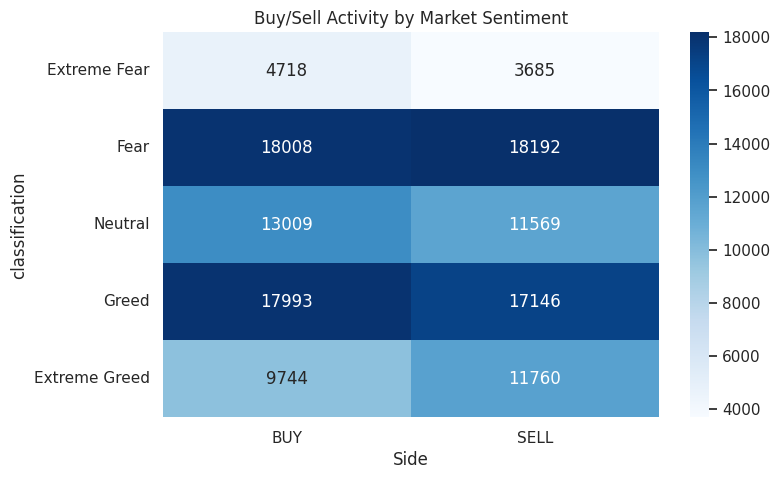

In [24]:
# Create Heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    trade_behavior,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Buy/Sell Activity by Market Sentiment")

plt.show()

## Insight

The heatmap shows that trading activity was highest during Fear and Greed market conditions.

Extreme Greed periods recorded comparatively higher SELL activity, possibly indicating profit-booking behavior after strong bullish movements.

Overall, market sentiment appears to strongly influence trader participation and trading decisions.

**Correlation Analysis**

In [25]:
# Create Correlation Matrix
correlation = merged[['Closed PnL', 'Size USD', 'Fee']].corr()
print(correlation)

            Closed PnL  Size USD       Fee
Closed PnL    1.000000  0.128577  0.102088
Size USD      0.128577  1.000000  0.725680
Fee           0.102088  0.725680  1.000000


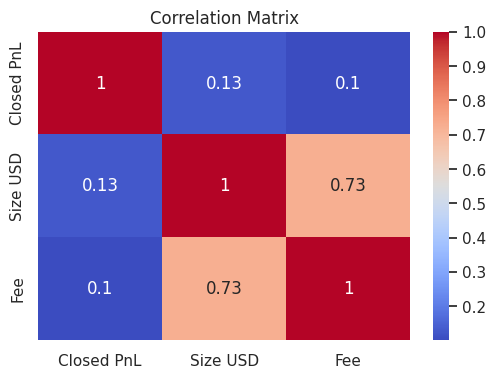

In [26]:
# Create Correlation Heatmap

plt.figure(figsize=(6,4))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Insight

A strong positive correlation was observed between trade size and transaction fees, as larger trades naturally generate higher fees.

However, Closed PnL showed only weak correlation with trade size, suggesting that larger trades do not necessarily lead to higher profits.

This indicates that profitability depends more on trading strategy and market conditions than trade volume alone.

**PnL Distribution Analysis**

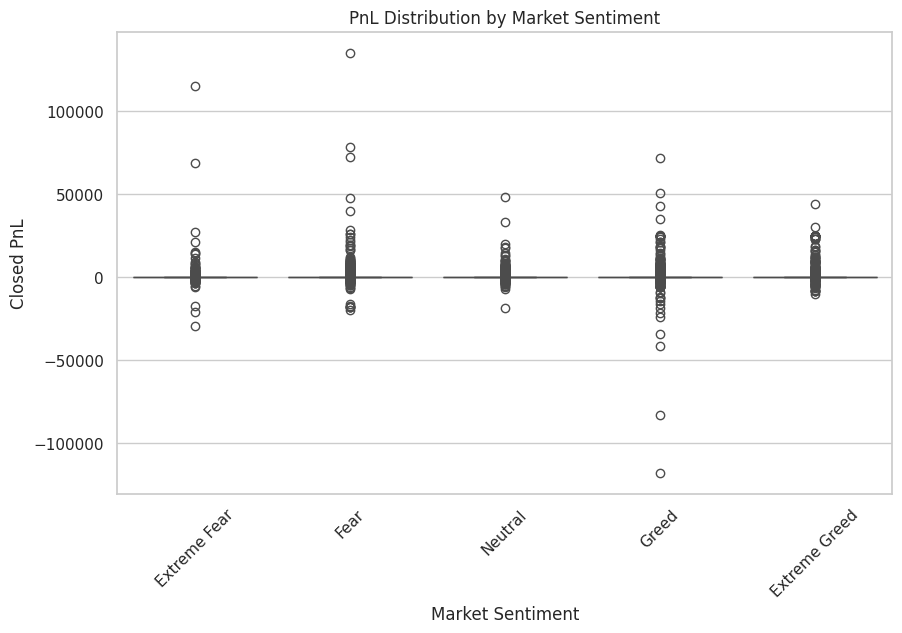

In [27]:
# Create Boxplot
plt.figure(figsize=(10,6))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged,
    order=order
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=45)

plt.show()

## Insight

The boxplot shows that most trades resulted in relatively smaller profit and loss values, while a few trades produced extremely large gains or losses.

Fear and Greed conditions displayed higher variability in trading outcomes, reflecting increased volatility and risk-taking behavior.

Extreme Greed periods also contained some of the largest positive profit outliers.

**Top Traded Coins Analysis**

---



In [28]:
# Find Most Traded Coins
top_coins = merged['Coin'].value_counts().head(10)
print(top_coins)

Coin
HYPE        40725
BTC         21149
@107        10357
ETH          7662
SOL          4050
MELANIA      2988
WLD          1978
kBONK        1492
FARTCOIN     1465
FTT          1397
Name: count, dtype: int64


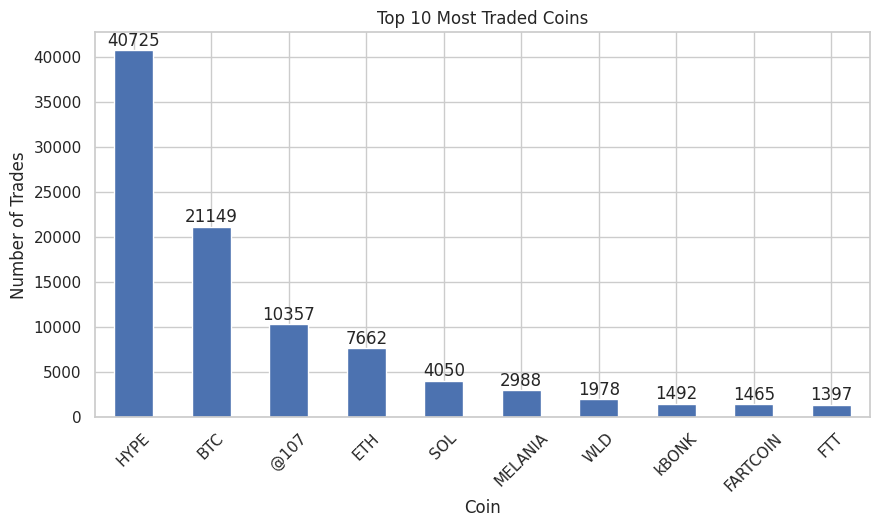

In [29]:
# Visualization
ax = top_coins.plot(kind='bar',figsize=(10,5))

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

# Add values on top
for i, v in enumerate(top_coins):
    ax.text(i, v + 500, str(v), ha='center')

plt.show()

## Insight

Trading activity was heavily concentrated in a small number of cryptocurrencies.

HYPE emerged as the most actively traded asset, followed by major coins such as BTC and ETH.

This suggests that traders primarily prefer highly liquid and high-interest markets for trading activity.

**Top Traders Analysis**

In [30]:
# Find Most Profitable Traders
top_traders = merged.groupby('Account')['Closed PnL'].sum()
top_traders = top_traders.sort_values(ascending=False).head(10)
print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
Name: Closed PnL, dtype: float64


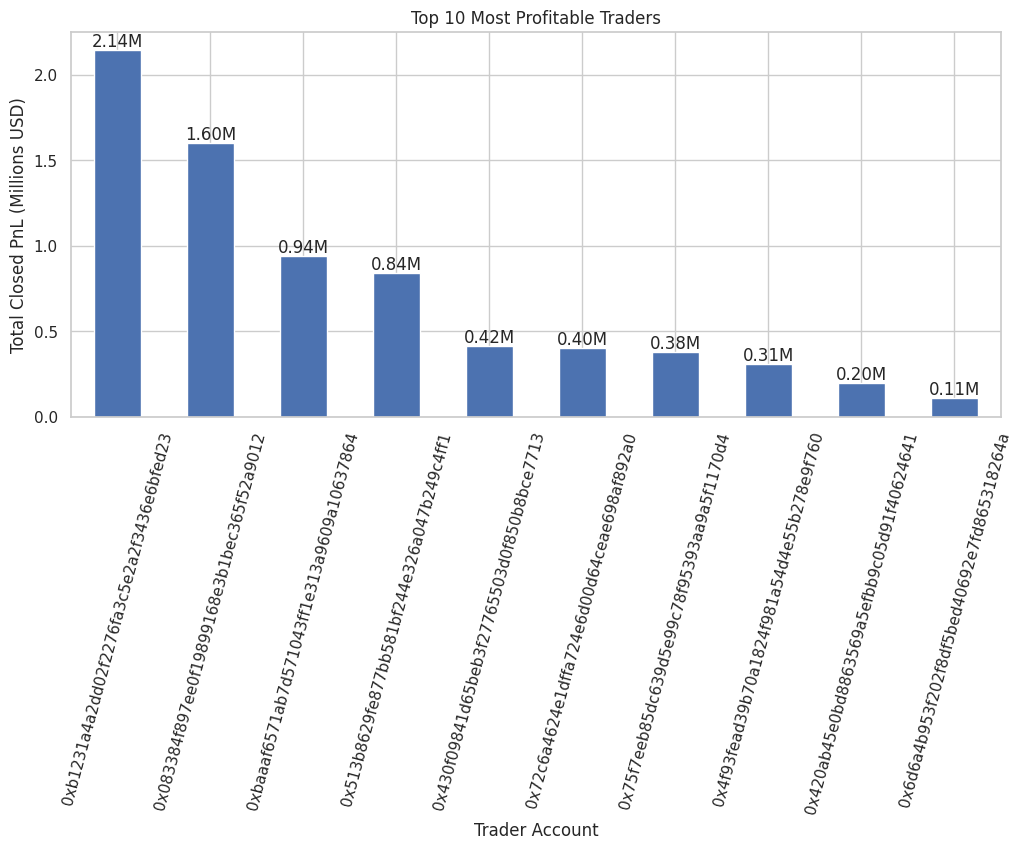

In [31]:
# Convert to millions
top_traders_million = top_traders / 1_000_000

ax = top_traders_million.plot(kind='bar',figsize=(12,5))

plt.title("Top 10 Most Profitable Traders")
plt.xlabel("Trader Account")
plt.ylabel("Total Closed PnL (Millions USD)")

plt.xticks(rotation=75)

# Add values on top
for i, v in enumerate(top_traders_million):
    ax.text(i,v + 0.02,f"{v:.2f}M",ha='center')
plt.show()

## Insight

Trader profitability was highly concentrated among a small number of accounts.

The top traders generated significantly larger cumulative profits compared to the majority of participants, with the leading trader earning more than 2 million USD.

This highlights the uneven distribution of trading success and the importance of strategy, timing, and market expertise.

**Coin-wise Profitability Analysis**

In [32]:
coin_pnl = merged.groupby('Coin')['Closed PnL'].mean()

coin_pnl = coin_pnl.sort_values(ascending=False).head(10)

print(coin_pnl)

Coin
@109      414.308178
AVAX      386.391806
DOGE      336.246872
SOL       291.843937
EIGEN     209.590802
@107      186.871446
PEOPLE    180.323003
ZRO       148.805126
ETHFI     141.250823
MANTA     139.230689
Name: Closed PnL, dtype: float64


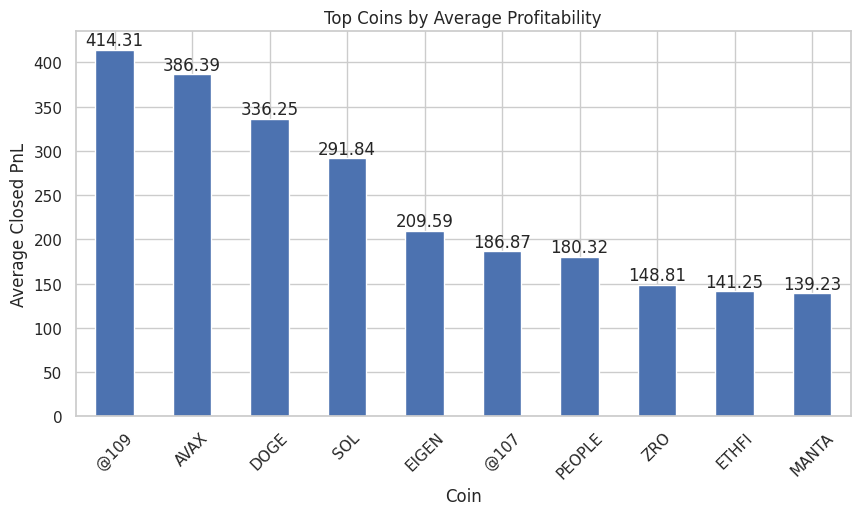

In [33]:
ax = coin_pnl.plot( kind='bar', figsize=(10,5))

plt.title("Top Coins by Average Profitability")
plt.xlabel("Coin")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

# Add values on top
for i, v in enumerate(coin_pnl):
    ax.text( i, v + 5, f"{v:.2f}", ha='center' )

plt.show()

## Insight

The coin-wise profitability analysis revealed major differences in average profitability across cryptocurrencies.

Coins such as AVAX, DOGE, and SOL generated higher average profits, indicating stronger trading opportunities and market momentum.

The results suggest that asset selection plays an important role in overall trading performance.

---------------------------------------------------------------

#**Final Conclusion**

1. The analysis showed that cryptocurrency market sentiment has a significant impact on trader behavior and trading performance.

2. Extreme Greed conditions produced the highest average profitability and win rates, indicating stronger bullish momentum and better trading opportunities.

3. Fear and Greed market phases showed higher variability in trading outcomes, reflecting increased volatility and emotional trading behavior.

4. Trading activity was concentrated mainly in a few highly active assets such as HYPE, BTC, and ETH.

5. Coin-wise profitability analysis revealed that asset selection plays an important role in trading success, with coins like AVAX, DOGE, and SOL generating higher average profits.

6. Correlation analysis showed a strong relationship between trade size and transaction fees, while profitability had only a weak relationship with trade size.

7. Profitability among traders was highly uneven, with a small number of traders generating exceptionally large cumulative profits.

8. Overall, the project demonstrates how market sentiment, trading behavior, and asset selection collectively influence profitability and participation within cryptocurrency markets.